In [1]:
import pandas as pd
import numpy as np
import openpyxl
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [2]:
df_gpts = pd.read_csv("./datasets/occ_level.csv")
# O*Net Datasets
df_abilities = pd.read_excel("./datasets/Abilities.xlsx")
df_job_zones = pd.read_excel("./datasets/Job Zones.xlsx")
df_occupation_data = pd.read_excel("./datasets/Occupation Data.xlsx")
df_related_occupations = pd.read_excel("./datasets/Related Occupations.xlsx")
df_transferable_skills = pd.read_excel("./datasets/Transferable Skills.xlsx")
df_work_context = pd.read_excel("./datasets/Work Context.xlsx")
df_work_styles = pd.read_excel("./datasets/Work Styles.xlsx")
df_occupation = pd.read_excel("./datasets/occupation.xlsx", sheet_name=2, header=1)
df_nem_one_soc = pd.read_excel("./datasets/nem-onet-to-soc-crosswalk.xlsx", header=4)
#
df_gpts =df_gpts[["O*NET-SOC Code", "Title", "human_rating_beta"]]


In [3]:
df_job_zones = df_job_zones[["O*NET-SOC Code", "Title" ,"Job Zone"]]
df_job_zones


,O*NET-SOC Code,Title,Job Zone
0,11-1011.00,Chief Executives,5
1,11-1011.03,Chief Sustainability Officers,5
2,11-1021.00,General and Operations Managers,4
3,11-1031.00,Legislators,4
4,11-2011.00,Advertising and Promotions Managers,4
...,...,...,...
918,53-7071.00,Gas Compressor and Gas Pumping Station Operators,2
919,53-7072.00,"Pump Operators, Except Wellhead Pumpers",2
920,53-7073.00,Wellhead Pumpers,2
921,53-7081.00,Refuse and Recyclable Material Collectors,2


In [4]:
df_occupation["2024 National Employment Matrix code"] = (
    df_occupation["2024 National Employment Matrix code"]
    .astype(str)
    .str.strip()
)

df_nem_one_soc["NEM Code"] = (
    df_nem_one_soc["NEM Code"]
    .astype(str)
    .str.strip()
)

df_occupation = df_occupation.merge(
    df_nem_one_soc[["NEM Code", "O*NET-SOC code"]],
    left_on="2024 National Employment Matrix code",
    right_on="NEM Code",
    how="left"
)


In [5]:
occupation_code_col = "2024 National Employment Matrix code"
occupation_title_col = "2024 National Employment Matrix title"

occupation_codes = (
    df_occupation["2024 National Employment Matrix code"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
)

nem_codes = (
    df_nem_one_soc["NEM Code"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
)


match_by_nem = occupation_codes.isin(nem_codes)

matched_codes = occupation_codes[match_by_nem]
unmatched_occupation_codes = occupation_codes[~match_by_nem]

merge_rate = len(matched_codes) / len(occupation_codes) * 100

print(f"Occupation codes: {len(occupation_codes)}")
print(f"Matched codes: {len(matched_codes)}")
print(f"Unmatched codes: {len(unmatched_occupation_codes)}")
print(f"Merge rate: {merge_rate:.2f}%")

df_unmatched = df_occupation[
    df_occupation[occupation_code_col]
    .astype(str)
    .str.strip()
    .isin(unmatched_occupation_codes)
][
    [occupation_code_col, occupation_title_col]
]

display(df_unmatched)

Occupation codes: 1113
Matched codes: 832
Unmatched codes: 281
Merge rate: 74.75%


,2024 National Employment Matrix code,2024 National Employment Matrix title
0,00-0000,"Total, all occupations"
1,11-0000,Management occupations
2,11-1000,Top executives
7,11-2000,"Advertising, marketing, promotions, public..."
9,11-2020,Marketing and sales managers
...,...,...
1246,53-6000,Other transportation workers
1249,53-6030,Transportation service attendants
1258,53-7000,Material moving workers
1264,53-7060,Laborers and material movers


In [6]:
df_occupation = df_occupation[["Employment, 2024", "Employment change, percent, 2024–34", "Occupational openings, 2024–34 annual average", "O*NET-SOC code"]]



In [7]:
df_new = pd.DataFrame(columns = ["onet_code", "occupation", "human_beta", "job zone", "openings_annual", "employment_growth_pct", "employment_2024"])


In [8]:
base = df_occupation_data[["O*NET-SOC Code", "Title"]].copy()
base.columns = ["onet_code", "occupation"]

gpt = df_gpts[["O*NET-SOC Code", "human_rating_beta"]].copy()
gpt.columns = ["onet_code", "human_beta"]

zones = df_job_zones[["O*NET-SOC Code", "Job Zone"]].copy()
zones.columns = ["onet_code", "job_zone"]

bls = df_occupation[
    [
        "O*NET-SOC code",
        "Employment, 2024",
        "Employment change, percent, 2024–34",
        "Occupational openings, 2024–34 annual average"
    ]
].copy()

bls.columns = [
    "onet_code",
    "employment_2024",
    "employment_growth_pct",
    "openings_annual"
]

In [9]:
for table in [base, gpt, zones, bls]:
    table["onet_code"] = table["onet_code"].astype(str).str.strip()

In [10]:
df_new = (
    base
    .merge(gpt, on="onet_code", how="inner")
    .merge(zones, on="onet_code", how="inner")
    .merge(bls, on="onet_code", how="inner")
    .drop_duplicates(subset="onet_code")
)

In [11]:
df_new["gpt_percentile"] = df_new["human_beta"].rank(pct=True) * 100

# Transparent project operationalization; not a replacement-share claim.
df_new["gpt_high"] = df_new["human_beta"] >= 0.50

# Labor-Market-Score: Kombination aus Beschaeftigungswachstum und jaehrlichen
# Stellenausschreibungen. Beide Groessen werden zuerst in Perzentil-Raenge (0-1)
# umgewandelt, damit unterschiedliche Skalen (Wachstum in % vs. absolute Anzahl)
# vergleichbar sind. 1.0 = bester Wert im Datensatz, 0.0 = schlechtester.
df_new["growth_rank"] = df_new["employment_growth_pct"].rank(pct=True)
df_new["openings_rank"] = df_new["openings_annual"].rank(pct=True)
df_new["labor_market_score"] = (df_new["growth_rank"] + df_new["openings_rank"]) / 2

In [12]:
print("GPT exposure threshold:", 0.50)

print("\nExposure groups:")
print(
    df_new["gpt_high"]
    .map({
        True: "Hoch GPT-exponiert",
        False: "Nicht hoch GPT-exponiert"
    })
    .value_counts()
)

print("\nShare highly GPT-exposed:")
print(round(df_new["gpt_high"].mean() * 100, 1), "%")

GPT exposure threshold: 0.5

Exposure groups:
gpt_high
Nicht hoch GPT-exponiert    724
Hoch GPT-exponiert          199
Name: count, dtype: int64

Share highly GPT-exposed:
21.6 %


In [13]:
print("Anzahl Berufe:", len(df_new))
print("Doppelte Codes:", df_new["onet_code"].duplicated().sum())

df_new

Anzahl Berufe: 923
Doppelte Codes: 0


,onet_code,occupation,human_beta,job_zone,employment_2024,employment_growth_pct,openings_annual,gpt_percentile,gpt_high,growth_rank,openings_rank,labor_market_score
0,11-1011.00,Chief Executives,0.350000,5,309.4,4.3,22.2,56.229686,False,0.661972,0.764897,0.713434
1,11-1011.03,Chief Sustainability Officers,0.388889,5,309.4,4.3,22.2,62.946912,False,0.661972,0.764897,0.713434
2,11-1021.00,General and Operations Managers,0.384615,4,3712.9,4.4,308.7,62.459372,False,0.676056,0.986999,0.831528
3,11-1031.00,Legislators,0.516667,4,27.7,3.4,2.2,81.906826,True,0.557963,0.283315,0.420639
4,11-2011.00,Advertising and Promotions Managers,0.546512,4,27.0,-2.2,2.1,86.673889,True,0.185807,0.274106,0.229957
...,...,...,...,...,...,...,...,...,...,...,...,...
918,53-7071.00,Gas Compressor and Gas Pumping Station Operators,0.076923,2,5.4,-1.3,0.6,19.772481,False,0.218852,0.085590,0.152221
919,53-7072.00,"Pump Operators, Except Wellhead Pumpers",0.166667,2,13.1,2.6,1.5,33.911159,False,0.474540,0.214518,0.344529
920,53-7073.00,Wellhead Pumpers,0.000000,2,18.8,-4.7,2.0,3.196100,False,0.128386,0.263814,0.196100
921,53-7081.00,Refuse and Recyclable Material Collectors,0.232143,2,147.9,0.9,16.9,40.574215,False,0.307151,0.722644,0.514897


In [14]:
df_new.to_csv(
    "./datasets/occupations_master.csv",
    index=False
)

In [15]:
print(df_related_occupations.columns.tolist())

df_related_occupations["Relatedness Tier"].value_counts()


['O*NET-SOC Code', 'Title', 'Related O*NET-SOC Code', 'Related Title', 'Relatedness Tier', 'Index']


Relatedness Tier
Supplemental     9230
Primary-Short    4615
Primary-Long     4615
Name: count, dtype: int64

In [16]:
# Wir behalten nur die 5 engsten verwandten Berufe.
routes = df_related_occupations[
    df_related_occupations["Relatedness Tier"] == "Primary-Short"
][
    [
        "O*NET-SOC Code",
        "Related O*NET-SOC Code"
    ]
].copy()

# Wir benennen die Codes verständlich um.
routes.columns = ["source_code", "target_code"]

# Wir entfernen Leerzeichen, damit die Codes beim Merge gleich geschrieben sind.
routes["source_code"] = routes["source_code"].astype(str).str.strip()
routes["target_code"] = routes["target_code"].astype(str).str.strip()

# Ein Beruf soll nicht als sein eigener Wechselberuf vorkommen.
routes = routes[routes["source_code"] != routes["target_code"]]

# Informationen über den Ausgangsberuf vorbereiten.
source = df_new[
    [
        "onet_code",
        "occupation",
        "gpt_percentile",
        "job_zone"
    ]
].copy()

# Spalten umbenennen, damit klar ist: Diese Daten gehören zum Ausgangsberuf.
source.columns = [
    "source_code",
    "source_occupation",
    "source_gpt_percentile",
    "source_job_zone"
]

# Informationen über den möglichen Zielberuf vorbereiten.
target = df_new[
    [
        "onet_code",
        "occupation",
        "gpt_percentile",
        "job_zone",
        "labor_market_score"
    ]
].copy()

# Spalten umbenennen, damit klar ist: Diese Daten gehören zum Zielberuf.
target.columns = [
    "target_code",
    "target_occupation",
    "target_gpt_percentile",
    "target_job_zone",
    "target_labor_market_score"
]

# Informationen des Ausgangsberufs an jede Route hängen.
routes = routes.merge(
    source,
    on="source_code",
    how="inner"
)

# Informationen des Zielberufs an jede Route hängen.
routes = routes.merge(
    target,
    on="target_code",
    how="inner"
)

# Kontrolle: Wie viele nutzbare Wechselrouten haben wir?
print("Anzahl verfügbarer Wechselrouten:", len(routes))

# Erste zehn Wechselrouten anzeigen.
display(routes.head(10))

Anzahl verfügbarer Wechselrouten: 4615


,source_code,target_code,source_occupation,source_gpt_percentile,source_job_zone,target_occupation,target_gpt_percentile,target_job_zone,target_labor_market_score
0,11-1011.00,11-1021.00,Chief Executives,56.229686,5,General and Operations Managers,62.459372,4,0.831528
1,11-1011.00,13-1111.00,Chief Executives,56.229686,5,Management Analysts,79.685807,4,0.919014
2,11-1011.00,11-3031.01,Chief Executives,56.229686,5,Treasurers and Controllers,66.197183,4,0.940683
3,11-1011.00,11-9151.00,Chief Executives,56.229686,5,Social and Community Service Managers,71.505959,4,0.784399
4,11-1011.00,11-2032.00,Chief Executives,56.229686,5,Public Relations Managers,89.111593,4,0.628927
5,11-1011.03,13-1199.05,Chief Sustainability Officers,62.946912,5,Sustainability Specialists,97.183099,4,0.725894
6,11-1011.03,19-2041.01,Chief Sustainability Officers,62.946912,5,Climate Change Policy Analysts,99.133261,5,0.623510
7,11-1011.03,19-2041.03,Chief Sustainability Officers,62.946912,5,Industrial Ecologists,98.483207,5,0.623510
8,11-1011.03,11-9199.10,Chief Sustainability Officers,62.946912,5,Wind Energy Development Managers,85.157096,4,0.817172
9,11-1011.03,19-2041.00,Chief Sustainability Officers,62.946912,5,"Environmental Scientists and Specialists, Incl...",98.591549,4,0.623510


In [17]:
# Unterschied der GPT-Exposition:
# Positiv = der Zielberuf ist weniger GPT-exponiert.
routes["gpt_gain"] = (
    routes["source_gpt_percentile"]
    - routes["target_gpt_percentile"]
)

# Unterschied bei der Job Zone:
# Positiv = der Zielberuf erfordert mehr Vorbereitung.
routes["job_zone_difference"] = (
    routes["target_job_zone"]
    - routes["source_job_zone"]
)

# Eine Route ist gut, wenn alle drei Bedingungen erfüllt sind.
routes["good_transition"] = (
    (routes["gpt_gain"] >= 10)
    & (routes["job_zone_difference"] <= 1)
    & (routes["target_labor_market_score"] >= 0.5)
)

# Wie viele gute Wechseloptionen gibt es insgesamt?
print("Gute Wechseloptionen:", routes["good_transition"].sum())

# Beispiele anzeigen
display(
    routes[
        [
            "source_occupation",
            "target_occupation",
            "gpt_gain",
            "job_zone_difference",
            "target_labor_market_score",
            "good_transition"
        ]
    ] .head(20)
)

Gute Wechseloptionen: 682


,source_occupation,target_occupation,gpt_gain,job_zone_difference,target_labor_market_score,good_transition
0,Chief Executives,General and Operations Managers,-6.229686,-1,0.831528,False
1,Chief Executives,Management Analysts,-23.456121,-1,0.919014,False
2,Chief Executives,Treasurers and Controllers,-9.967497,-1,0.940683,False
3,Chief Executives,Social and Community Service Managers,-15.276273,-1,0.784399,False
4,Chief Executives,Public Relations Managers,-32.881907,-1,0.628927,False
5,Chief Sustainability Officers,Sustainability Specialists,-34.236186,-1,0.725894,False
6,Chief Sustainability Officers,Climate Change Policy Analysts,-36.186349,0,0.623510,False
7,Chief Sustainability Officers,Industrial Ecologists,-35.536295,0,0.623510,False
8,Chief Sustainability Officers,Wind Energy Development Managers,-22.210184,-1,0.817172,False
9,Chief Sustainability Officers,"Environmental Scientists and Specialists, Incl...",-35.644637,-1,0.623510,False


In [18]:
transition_scores = (
    routes
    .groupby(["source_code", "source_occupation"])
    .agg(
        valid_routes=("target_code", "count"),
        good_transitions=("good_transition", "sum")
    )
    .reset_index()
)

transition_scores["transition_score"] = (
    transition_scores["good_transitions"]
    / transition_scores["valid_routes"]
)

transition_scores.columns = [
    "onet_code",
    "occupation",
    "valid_routes",
    "good_transitions",
    "transition_score"
]

display(
    transition_scores
    .sort_values("transition_score", ascending=False)
    .head(15)
)

,onet_code,occupation,valid_routes,good_transitions,transition_score
873,53-1042.01,Recycling Coordinators,5,5,1.0
436,29-2011.01,Cytogenetic Technologists,5,5,1.0
35,11-9051.00,Food Service Managers,5,5,1.0
590,43-1011.00,First-Line Supervisors of Office and Administr...,5,5,1.0
673,47-2131.00,"Insulation Workers, Floor, Ceiling, and Wall",5,5,1.0
18,11-3051.02,Geothermal Production Managers,5,4,0.8
89,13-2022.00,Appraisers of Personal and Business Property,5,4,0.8
75,13-1081.02,Logistics Analysts,5,4,0.8
67,13-1041.07,Regulatory Affairs Specialists,5,4,0.8
392,29-1123.00,Physical Therapists,5,4,0.8


In [19]:
df_labeled = df_new.merge(
    transition_scores[
        [
            "onet_code",
            "valid_routes",
            "good_transitions",
            "transition_score"
        ]
    ],
    on="onet_code",
    how="left"
)
df_labeled = df_labeled.drop_duplicates(subset="onet_code").copy()

df_labeled["valid_routes"] = df_labeled["valid_routes"].fillna(0)
df_labeled["good_transitions"] = df_labeled["good_transitions"].fillna(0)
df_labeled["transition_score"] = df_labeled["transition_score"].fillna(0)

In [20]:
df_labeled["target_label"] = np.select(
    [
        # Nicht hoch GPT-exponiert nach der human_beta-Schwelle von 0.50
        ~df_labeled["gpt_high"],

        # Hoch exponiert und mindestens 2 gute Wechseloptionen
        df_labeled["gpt_high"]
        & (df_labeled["good_transitions"] >= 2)
    ],
    [
        "Nicht hoch GPT-exponiert",
        "Hoch GPT-exponiert mit guten Wechseloptionen"
    ],
    default="Hoch GPT-exponiert mit begrenzten Wechseloptionen"
)

In [21]:
print("Final label distribution:")
print(df_labeled["target_label"].value_counts())

print("\nDuplicate O*NET codes:")
print(df_labeled["onet_code"].duplicated().sum())

Final label distribution:
target_label
Nicht hoch GPT-exponiert                             724
Hoch GPT-exponiert mit begrenzten Wechseloptionen    113
Hoch GPT-exponiert mit guten Wechseloptionen          86
Name: count, dtype: int64

Duplicate O*NET codes:
0


In [22]:
print(df_labeled["target_label"].value_counts())

display(
    df_labeled[
        [
            "occupation",
            "gpt_percentile",
            "valid_routes",
            "good_transitions",
            "transition_score",
            "target_label"
        ]
    ]
    .sort_values("gpt_percentile", ascending=False)
    .head(20)
)

target_label
Nicht hoch GPT-exponiert                             724
Hoch GPT-exponiert mit begrenzten Wechseloptionen    113
Hoch GPT-exponiert mit guten Wechseloptionen          86
Name: count, dtype: int64


,occupation,gpt_percentile,valid_routes,good_transitions,transition_score,target_label
226,Survey Researchers,99.945829,5,1,0.2,Hoch GPT-exponiert mit begrenzten Wechseloptionen
196,Animal Scientists,99.945829,5,3,0.6,Hoch GPT-exponiert mit guten Wechseloptionen
370,Interpreters and Translators,99.783315,5,2,0.4,Hoch GPT-exponiert mit guten Wechseloptionen
368,Writers and Authors,99.674973,5,1,0.2,Hoch GPT-exponiert mit begrenzten Wechseloptionen
600,Brokerage Clerks,99.566631,5,2,0.4,Hoch GPT-exponiert mit guten Wechseloptionen
365,Public Relations Specialists,99.458288,5,1,0.2,Hoch GPT-exponiert mit begrenzten Wechseloptionen
225,Environmental Economists,99.349946,5,0,0.0,Hoch GPT-exponiert mit begrenzten Wechseloptionen
629,Legal Secretaries and Administrative Assistants,99.241603,5,2,0.4,Hoch GPT-exponiert mit guten Wechseloptionen
218,Climate Change Policy Analysts,99.133261,5,1,0.2,Hoch GPT-exponiert mit begrenzten Wechseloptionen
628,Executive Secretaries and Executive Administra...,99.024919,5,4,0.8,Hoch GPT-exponiert mit guten Wechseloptionen


In [23]:
df_labeled.to_csv(
    "./datasets/occupations_with_labels.csv",
    index=False
)

In [24]:
for name, table in {
    "Abilities": df_abilities,
    "Work Context": df_work_context,
    "Work Styles": df_work_styles
}.items():

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("\nSpalten:")
    print(table.columns.tolist())

    print("\nScale IDs:")
    print(table["Scale ID"].value_counts(dropna=False))


Abilities

Spalten:
['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Not Relevant', 'Date', 'Domain Source']

Scale IDs:
Scale ID
IM    46488
LV    46488
Name: count, dtype: int64

Work Context

Spalten:
['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Category', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Not Relevant', 'Date', 'Domain Source']

Scale IDs:
Scale ID
CXP    241450
CX      49170
CTP      5268
CT       1788
Name: count, dtype: int64

Work Styles

Spalten:
['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Data Value', 'Date', 'Domain Source']

Scale IDs:
Scale ID
DR    18711
WI    18711
Name: count, dtype: int64


In [25]:
# Dateien frisch laden, damit keine Zeilen aus Versehen entfernt wurden

abilities_raw = pd.read_excel("./datasets/Abilities.xlsx")
work_styles_raw = pd.read_excel("./datasets/Work Styles.xlsx")

print(abilities_raw["Scale ID"].value_counts())
print(work_styles_raw["Scale ID"].value_counts())

Scale ID
IM    46488
LV    46488
Name: count, dtype: int64
Scale ID
DR    18711
WI    18711
Name: count, dtype: int64


In [26]:
# Bei Abilities nehmen wir LV = Level der Fähigkeit

abilities = df_abilities[
    df_abilities["Scale ID"] == "LV"
][
    ["O*NET-SOC Code", "Element Name", "Data Value"]
].dropna(
    subset=["O*NET-SOC Code", "Element Name", "Data Value"]
)

# Jede Fähigkeit wird eine eigene Spalte
abilities = abilities.pivot_table(
    index="O*NET-SOC Code",
    columns="Element Name",
    values="Data Value",
    aggfunc="mean"
).reset_index()

# Berufscode umbenennen
abilities = abilities.rename(
    columns={"O*NET-SOC Code": "onet_code"}
)

# Codes vereinheitlichen
abilities["onet_code"] = abilities["onet_code"].astype(str).str.strip()

# ability_ vor jede Merkmals-Spalte setzen
abilities = abilities.rename(
    columns={
        col: f"ability_{col}"
        for col in abilities.columns
        if col != "onet_code"
    }
)

print("Abilities-Berufe:", len(abilities))
print("Abilities-Merkmale:", len(abilities.columns) - 1)

display(abilities.head())

Abilities-Berufe: 894
Abilities-Merkmale: 52


Element Name,onet_code,ability_Arm-Hand Steadiness,ability_Auditory Attention,ability_Category Flexibility,ability_Control Precision,ability_Deductive Reasoning,ability_Depth Perception,ability_Dynamic Flexibility,ability_Dynamic Strength,ability_Explosive Strength,...,ability_Speed of Limb Movement,ability_Stamina,ability_Static Strength,ability_Time Sharing,ability_Trunk Strength,ability_Visual Color Discrimination,ability_Visualization,ability_Wrist-Finger Speed,ability_Written Comprehension,ability_Written Expression
0,11-1011.00,0.50,2.00,4.00,0.75,4.75,1.38,0.0,0.25,0.00,...,0.0,0.00,0.00,2.88,0.62,2.00,3.38,0.50,4.88,4.75
1,11-1011.03,0.00,1.75,3.50,0.50,4.75,1.75,0.0,0.00,0.00,...,0.0,0.00,0.00,2.38,0.50,2.00,2.88,0.12,4.25,4.38
2,11-1021.00,0.88,2.00,3.25,0.12,4.12,1.62,0.0,0.12,0.38,...,0.0,0.88,0.88,2.88,1.88,1.75,2.75,0.88,4.00,4.00
3,11-2011.00,0.50,1.25,3.88,0.12,4.50,1.00,0.0,0.00,0.00,...,0.0,0.00,0.00,2.12,0.88,2.75,3.12,0.75,4.00,4.00
4,11-2021.00,0.12,1.62,3.62,0.00,4.38,0.75,0.0,0.25,0.00,...,0.0,0.00,0.00,2.62,0.88,2.88,3.00,0.75,4.12,4.12


In [27]:
# Bei Work Styles nehmen wir WI = Work Importance.
# DR ist nur ein Rangwert und nicht für das Modell geeignet.

work_styles = df_work_styles[
    df_work_styles["Scale ID"] == "WI"
][
    ["O*NET-SOC Code", "Element Name", "Data Value"]
].dropna(
    subset=["O*NET-SOC Code", "Element Name", "Data Value"]
)

# Jeder Arbeitsstil wird eine eigene Spalte
work_styles = work_styles.pivot_table(
    index="O*NET-SOC Code",
    columns="Element Name",
    values="Data Value",
    aggfunc="mean"
).reset_index()

# Berufscode umbenennen
work_styles = work_styles.rename(
    columns={"O*NET-SOC Code": "onet_code"}
)

# Codes vereinheitlichen
work_styles["onet_code"] = work_styles["onet_code"].astype(str).str.strip()

# style_ vor jede Merkmals-Spalte setzen
work_styles = work_styles.rename(
    columns={
        col: f"style_{col}"
        for col in work_styles.columns
        if col != "onet_code"
    }
)

print("Work-Styles-Berufe:", len(work_styles))
print("Work-Styles-Merkmale:", len(work_styles.columns) - 1)

display(work_styles.head())

Work-Styles-Berufe: 891
Work-Styles-Merkmale: 21


Element Name,onet_code,style_Achievement Orientation,style_Adaptability,style_Attention to Detail,style_Cautiousness,style_Cooperation,style_Dependability,style_Empathy,style_Humility,style_Initiative,...,style_Intellectual Curiosity,style_Leadership Orientation,style_Optimism,style_Perseverance,style_Self-Confidence,style_Self-Control,style_Sincerity,style_Social Orientation,style_Stress Tolerance,style_Tolerance for Ambiguity
0,11-1011.00,2.91,2.69,1.44,1.03,1.53,2.93,1.07,-0.27,2.50,...,2.16,3.00,1.60,2.46,2.69,2.42,0.96,2.26,2.55,2.05
1,11-1021.00,2.38,2.05,1.74,1.32,1.84,2.65,1.22,0.12,2.22,...,1.44,2.93,1.39,2.19,2.28,2.14,0.94,1.97,1.99,1.64
2,11-1031.00,2.28,2.38,1.47,1.00,2.18,2.65,1.77,-0.10,2.22,...,2.41,3.00,1.42,2.34,2.44,2.30,1.07,2.54,2.43,2.03
3,11-2011.00,2.31,2.13,1.86,-0.44,1.84,2.22,0.95,-0.73,1.96,...,1.44,2.52,1.63,1.77,2.24,1.37,0.57,2.45,1.80,1.72
4,11-2021.00,2.38,2.30,1.62,0.32,1.50,2.14,1.05,-0.50,2.03,...,1.97,2.40,1.46,1.87,2.20,1.43,0.62,2.20,1.80,1.72


In [28]:
df_model = (
    df_labeled
    .merge(abilities, on="onet_code", how="inner")
    .merge(work_styles, on="onet_code", how="inner")
    .dropna(subset=["target_label"])
    .drop_duplicates(subset="onet_code")
)

print("Berufe im Modell-Datensatz:", len(df_model))
print("Doppelte Codes:", df_model["onet_code"].duplicated().sum())

print("\nKlassen:")
print(df_model["target_label"].value_counts())

display(df_model.head())

Berufe im Modell-Datensatz: 862
Doppelte Codes: 0

Klassen:
target_label
Nicht hoch GPT-exponiert                             687
Hoch GPT-exponiert mit begrenzten Wechseloptionen     96
Hoch GPT-exponiert mit guten Wechseloptionen          79
Name: count, dtype: int64


,onet_code,occupation,human_beta,job_zone,employment_2024,employment_growth_pct,openings_annual,gpt_percentile,gpt_high,growth_rank,...,style_Intellectual Curiosity,style_Leadership Orientation,style_Optimism,style_Perseverance,style_Self-Confidence,style_Self-Control,style_Sincerity,style_Social Orientation,style_Stress Tolerance,style_Tolerance for Ambiguity
0,11-1011.00,Chief Executives,0.350000,5,309.4,4.3,22.2,56.229686,False,0.661972,...,2.16,3.00,1.60,2.46,2.69,2.42,0.96,2.26,2.55,2.05
1,11-1021.00,General and Operations Managers,0.384615,4,3712.9,4.4,308.7,62.459372,False,0.676056,...,1.44,2.93,1.39,2.19,2.28,2.14,0.94,1.97,1.99,1.64
2,11-2011.00,Advertising and Promotions Managers,0.546512,4,27.0,-2.2,2.1,86.673889,True,0.185807,...,1.44,2.52,1.63,1.77,2.24,1.37,0.57,2.45,1.80,1.72
3,11-2021.00,Marketing Managers,0.578125,4,407.0,6.6,34.3,89.815818,True,0.833153,...,1.97,2.40,1.46,1.87,2.20,1.43,0.62,2.20,1.80,1.72
4,11-2022.00,Sales Managers,0.483333,4,619.5,4.7,49.0,76.923077,False,0.711268,...,1.17,2.71,1.71,2.46,2.40,1.91,0.94,2.54,1.93,1.51


In [29]:
# Gewünschte Arbeitskontext-Merkmale
context_features = [
    "Contact With Others",
    "Face-to-Face Discussions with Individuals and Within Teams",
    "Physical Proximity",
    "Electronic Mail",
    "Time Pressure",
    "Importance of Being Exact or Accurate",
    "Freedom to Make Decisions",
    "Spend Time Making Repetitive Motions"
]

# Nur CX-Werte und die gewünschten Merkmale behalten
work_context = df_work_context[
    (df_work_context["Scale ID"] == "CX")
    & (df_work_context["Element Name"].isin(context_features))
][
    ["O*NET-SOC Code", "Element Name", "Data Value"]
].dropna()

# Prüfen, ob alle gewünschten Merkmale gefunden wurden
print("Gefundene Kontextmerkmale:")
print(work_context["Element Name"].unique())

Gefundene Kontextmerkmale:
<StringArray>
['Face-to-Face Discussions with Individuals and Within Teams',
                                        'Contact With Others',
                                         'Physical Proximity',
                       'Spend Time Making Repetitive Motions',
                                  'Freedom to Make Decisions',
                      'Importance of Being Exact or Accurate',
                                              'Time Pressure']
Length: 7, dtype: str


In [30]:
work_context = work_context.pivot_table(
    index="O*NET-SOC Code",
    columns="Element Name",
    values="Data Value",
    aggfunc="mean"
).reset_index()

work_context = work_context.rename(
    columns={"O*NET-SOC Code": "onet_code"}
)

work_context["onet_code"] = (
    work_context["onet_code"]
    .astype(str)
    .str.strip()
)

# context_ vor jede neue Feature-Spalte setzen
work_context = work_context.rename(
    columns={
        col: f"context_{col}"
        for col in work_context.columns
        if col != "onet_code"
    }
)

print("Berufe mit Work-Context-Daten:", len(work_context))
display(work_context.head())

Berufe mit Work-Context-Daten: 894


Element Name,onet_code,context_Contact With Others,context_Face-to-Face Discussions with Individuals and Within Teams,context_Freedom to Make Decisions,context_Importance of Being Exact or Accurate,context_Physical Proximity,context_Spend Time Making Repetitive Motions,context_Time Pressure
0,11-1011.00,4.58,4.90,4.95,4.47,2.67,2.55,4.16
1,11-1011.03,4.41,4.67,4.37,3.52,2.78,2.00,3.48
2,11-1021.00,4.63,4.86,4.81,4.24,3.20,2.42,4.08
3,11-2011.00,4.68,4.87,4.04,4.30,2.82,2.50,4.40
4,11-2021.00,4.61,4.76,4.42,3.81,2.89,2.73,4.21


In [31]:
df_model = (
    df_labeled
    .merge(abilities, on="onet_code", how="inner")
    .merge(work_styles, on="onet_code", how="inner")
    .merge(work_context, on="onet_code", how="inner")
    .dropna(subset=["target_label"])
    .drop_duplicates(subset="onet_code")
)

print("Berufe im finalen Modell-Datensatz:", len(df_model))
print("Doppelte Codes:", df_model["onet_code"].duplicated().sum())

print("\nKlassenverteilung:")
print(df_model["target_label"].value_counts())

display(df_model.head())

Berufe im finalen Modell-Datensatz: 862
Doppelte Codes: 0

Klassenverteilung:
target_label
Nicht hoch GPT-exponiert                             687
Hoch GPT-exponiert mit begrenzten Wechseloptionen     96
Hoch GPT-exponiert mit guten Wechseloptionen          79
Name: count, dtype: int64


,onet_code,occupation,human_beta,job_zone,employment_2024,employment_growth_pct,openings_annual,gpt_percentile,gpt_high,growth_rank,...,style_Social Orientation,style_Stress Tolerance,style_Tolerance for Ambiguity,context_Contact With Others,context_Face-to-Face Discussions with Individuals and Within Teams,context_Freedom to Make Decisions,context_Importance of Being Exact or Accurate,context_Physical Proximity,context_Spend Time Making Repetitive Motions,context_Time Pressure
0,11-1011.00,Chief Executives,0.350000,5,309.4,4.3,22.2,56.229686,False,0.661972,...,2.26,2.55,2.05,4.58,4.90,4.95,4.47,2.67,2.55,4.16
1,11-1021.00,General and Operations Managers,0.384615,4,3712.9,4.4,308.7,62.459372,False,0.676056,...,1.97,1.99,1.64,4.63,4.86,4.81,4.24,3.20,2.42,4.08
2,11-2011.00,Advertising and Promotions Managers,0.546512,4,27.0,-2.2,2.1,86.673889,True,0.185807,...,2.45,1.80,1.72,4.68,4.87,4.04,4.30,2.82,2.50,4.40
3,11-2021.00,Marketing Managers,0.578125,4,407.0,6.6,34.3,89.815818,True,0.833153,...,2.20,1.80,1.72,4.61,4.76,4.42,3.81,2.89,2.73,4.21
4,11-2022.00,Sales Managers,0.483333,4,619.5,4.7,49.0,76.923077,False,0.711268,...,2.54,1.93,1.51,4.86,4.65,4.24,3.38,3.30,1.52,3.90


In [32]:
def build_feature_matrix(df, prefixes=("ability_", "style_", "context_")):
    """Waehlt Feature-Spalten per Prefix aus, erzwingt numerische Werte
    und ersetzt fehlende Werte durch den Spalten-Median."""
    feature_cols = [col for col in df.columns if col.startswith(prefixes)]
    X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
    X = X.fillna(X.median())
    return feature_cols, X

# X = Eingabemerkmale für den Random Forest
# y = Zielklasse, die vorhergesagt werden soll
feature_cols, X = build_feature_matrix(df_model)
y = df_model["target_label"].copy()

print("Anzahl Features:", len(feature_cols))
print("\nKlassenverteilung:")
print(y.value_counts())

print("\nFehlende Werte nach Bereinigung:")
print(X.isna().sum().sum())

Anzahl Features: 80

Klassenverteilung:
target_label
Nicht hoch GPT-exponiert                             687
Hoch GPT-exponiert mit begrenzten Wechseloptionen     96
Hoch GPT-exponiert mit guten Wechseloptionen          79
Name: count, dtype: int64

Fehlende Werte nach Bereinigung:
0


In [33]:
label_only_cols = {
    "human_beta",
    "gpt_percentile",
    "gpt_high",
    "valid_routes",
    "good_transitions",
    "transition_score",
    "job_zone",
    "openings_annual",
    "employment_growth_pct",
    "employment_2024",
    "openings_rank",
    "growth_rank",
    "labor_market_score",
}

def validate_no_leakage(feature_cols, label_only_cols, model_name):
    """Stellt sicher, dass keine Label-/Filter-Spalten als Modell-Feature landen."""
    leaked = sorted(set(feature_cols) & label_only_cols)
    assert not leaked, (
        f"Label/filter columns leaked into {model_name} features: "
        + ", ".join(leaked)
    )
    print(f"{model_name}: feature columns validated ({len(feature_cols)}).")

validate_no_leakage(feature_cols, label_only_cols, "Random Forest (target_label)")

Random Forest (target_label): feature columns validated (80).


In [34]:
# 80 % der Berufe zum Trainieren
# 20 % der Berufe zum späteren Testen
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Test:", len(X_test))

Training: 689
Test: 173


In [35]:
rf = RandomForestClassifier(
    n_estimators=500,      # 500 Entscheidungsbäume
    random_state=42,       # Ergebnisse bleiben reproduzierbar
    class_weight="balanced",  # wichtig, weil eure Klassen unterschiedlich groß sind
    min_samples_leaf=2,    # verhindert zu starke Überanpassung
    n_jobs=-1              # nutzt alle Prozessorkerne
)

rf.fit(X_train, y_train)

print("Random Forest wurde trainiert.")

Random Forest wurde trainiert.


In [36]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

# Vorhersagen für die Testdaten
y_pred = rf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, y_pred), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.775
Balanced Accuracy: 0.637

Classification Report:
                                                   precision    recall  f1-score   support

Hoch GPT-exponiert mit begrenzten Wechseloptionen       0.34      0.58      0.43        19
     Hoch GPT-exponiert mit guten Wechseloptionen       0.38      0.50      0.43        16
                         Nicht hoch GPT-exponiert       0.96      0.83      0.89       138

                                         accuracy                           0.77       173
                                        macro avg       0.56      0.64      0.59       173
                                     weighted avg       0.84      0.77      0.80       173



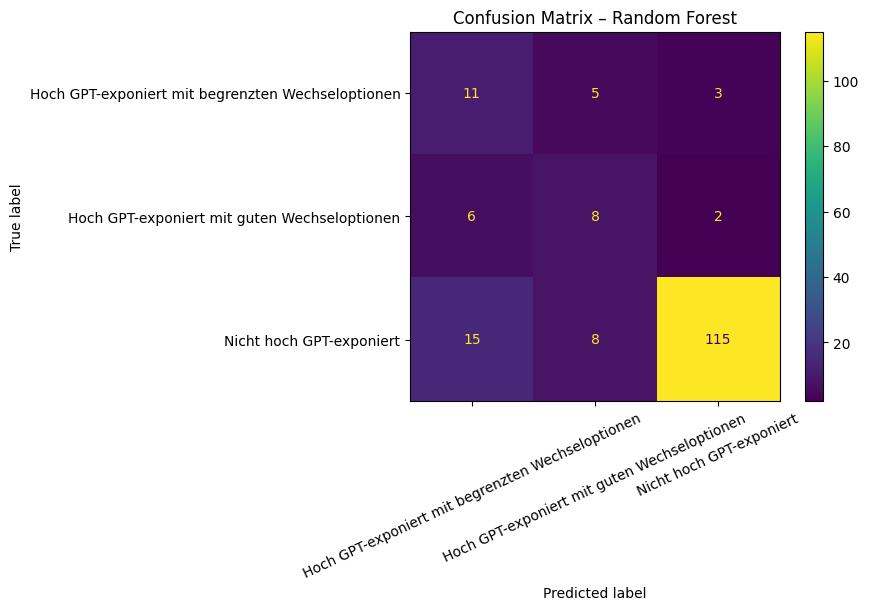

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=25
)

plt.title("Confusion Matrix – Random Forest")
plt.show()

In [38]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    rf,
    X,
    y,
    cv=cv,
    scoring=[
        "balanced_accuracy",
        "f1_macro",
        "accuracy"
    ],
    n_jobs=-1
)

print("Balanced Accuracy:",
      round(scores["test_balanced_accuracy"].mean(), 3),
      "+/-",
      round(scores["test_balanced_accuracy"].std(), 3)
)

print("Macro F1:",
      round(scores["test_f1_macro"].mean(), 3),
      "+/-",
      round(scores["test_f1_macro"].std(), 3)
)

print("Accuracy:",
      round(scores["test_accuracy"].mean(), 3),
      "+/-",
      round(scores["test_accuracy"].std(), 3)
)

Balanced Accuracy: 0.614 +/- 0.062
Macro F1: 0.559 +/- 0.038
Accuracy: 0.764 +/- 0.014


                                                   precision    recall  f1-score   support

Hoch GPT-exponiert mit begrenzten Wechseloptionen       0.37      0.64      0.46        96
     Hoch GPT-exponiert mit guten Wechseloptionen       0.30      0.38      0.34        79
                         Nicht hoch GPT-exponiert       0.95      0.83      0.89       687

                                         accuracy                           0.76       862
                                        macro avg       0.54      0.61      0.56       862
                                     weighted avg       0.83      0.76      0.79       862



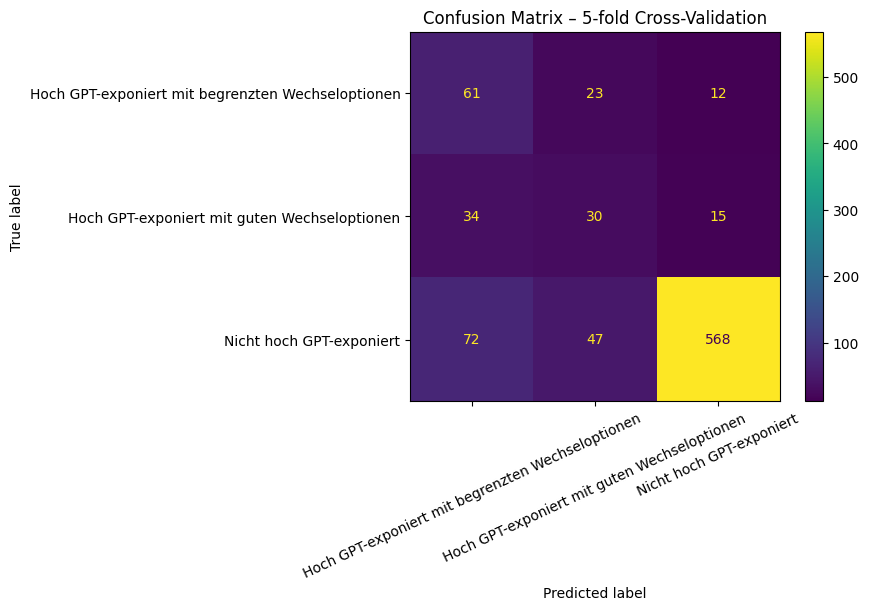

In [39]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Vorhersagen für alle Berufe per 5-facher Cross-Validation
y_cv_pred = cross_val_predict(
    rf,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

# Bericht für alle Klassen
print(classification_report(y, y_cv_pred))

# Confusion Matrix über alle Cross-Validation-Vorhersagen
ConfusionMatrixDisplay.from_predictions(
    y,
    y_cv_pred,
    xticks_rotation=25
)

plt.title("Confusion Matrix – 5-fold Cross-Validation")
plt.show()

In [40]:
print(df_transferable_skills.columns.tolist())

print(
    df_transferable_skills["Scale ID"]
    .value_counts(dropna=False)
)

['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Not Relevant', 'Date', 'Domain Source']
Scale ID
IM    22350
LV    22350
Name: count, dtype: int64


In [41]:
# Nur hoch GPT-exponierte Berufe auswählen
df_high = df_model[df_model["gpt_high"]].copy()

# Neue binäre Zielvariable:
# good = mindestens 2 gute Wechseloptionen
# limited = weniger als 2 gute Wechseloptionen
df_high["transition_label"] = np.where(
    df_high["good_transitions"] >= 2,
    "Gute Wechseloptionen",
    "Begrenzte Wechseloptionen"
)

print(df_high["transition_label"].value_counts())

transition_label
Begrenzte Wechseloptionen    96
Gute Wechseloptionen         79
Name: count, dtype: int64


In [42]:
feature_cols, X_high = build_feature_matrix(df_high)
y_high = df_high["transition_label"]

print("Anzahl Berufe:", len(df_high))
print(y_high.value_counts())

Anzahl Berufe: 175
transition_label
Begrenzte Wechseloptionen    96
Gute Wechseloptionen         79
Name: count, dtype: int64


In [43]:
validate_no_leakage(feature_cols, label_only_cols, "Transition Random Forest")

Transition Random Forest: feature columns validated (80).


In [44]:
rf_transition = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced_subsample",
    min_samples_leaf=3,
    max_features="sqrt",
    n_jobs=-1
)

cv_high = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_high = cross_validate(
    rf_transition,
    X_high,
    y_high,
    cv=cv_high,
    scoring=[
        "balanced_accuracy",
        "f1_macro",
        "recall_macro"
    ],
    n_jobs=-1
)

print(
    "Balanced Accuracy:",
    round(scores_high["test_balanced_accuracy"].mean(), 3),
    "+/-",
    round(scores_high["test_balanced_accuracy"].std(), 3)
)

print(
    "Macro F1:",
    round(scores_high["test_f1_macro"].mean(), 3),
    "+/-",
    round(scores_high["test_f1_macro"].std(), 3)
)

Balanced Accuracy: 0.629 +/- 0.107
Macro F1: 0.627 +/- 0.109


In [45]:
df_high_exposed = df_new[df_new["gpt_percentile"] >= 50].sort_values("gpt_percentile", ascending=False)
display(df_high_exposed[["onet_code", "occupation", "human_beta", "gpt_percentile"]])

,onet_code,occupation,human_beta,gpt_percentile
226,19-3022.00,Survey Researchers,0.843750,99.945829
196,19-1011.00,Animal Scientists,0.843750,99.945829
370,27-3091.00,Interpreters and Translators,0.840000,99.783315
368,27-3043.00,Writers and Authors,0.807692,99.674973
600,43-4011.00,Brokerage Clerks,0.800000,99.566631
...,...,...,...,...
354,27-2012.05,Media Technical Directors/Managers,0.307692,50.433369
874,53-1043.00,First-Line Supervisors of Material-Moving Mach...,0.307692,50.433369
319,25-2051.00,"Special Education Teachers, Preschool",0.307143,50.270856
878,53-2021.00,Air Traffic Controllers,0.306818,50.162514


In [ ]:
df_high_exposed = df_new[df_new["gpt_high"]].sort_values("human_beta", ascending=False)
display(df_high_exposed[["onet_code", "occupation", "human_beta", "gpt_percentile"]])
df_mathem = df_new[df_new["occupation"] == "Mathematicians"]


,onet_code,occupation,human_beta,gpt_percentile
196,19-1011.00,Animal Scientists,0.843750,99.945829
226,19-3022.00,Survey Researchers,0.843750,99.945829
370,27-3091.00,Interpreters and Translators,0.840000,99.783315
368,27-3043.00,Writers and Authors,0.807692,99.674973
600,43-4011.00,Brokerage Clerks,0.800000,99.566631
...,...,...,...,...
332,25-4022.00,Librarians and Media Collections Specialists,0.500000,79.685807
399,29-1129.02,Music Therapists,0.500000,79.685807
329,25-4011.00,Archivists,0.500000,79.685807
610,43-4131.00,Loan Interviewers and Clerks,0.500000,79.685807


,onet_code,occupation,human_beta,job_zone,employment_2024,employment_growth_pct,openings_annual,gpt_percentile,gpt_high,growth_rank,openings_rank,labor_market_score
132,15-2021.00,Mathematicians,0.690476,5,2.4,-0.7,0.1,97.616468,True,0.238353,0.011376,0.124865
